# Week 3 - Day 12
# Project 1 - Model Training

## Objective
Build, train and evaluate classification models on the project dataset (`Classification_dataset.csv`).

This notebook performs:
- Data Loading
- EDA
- Encoding
- Feature Scaling
- Train/Test Split
- Logistic Regression
- Random Forest
- Model Evaluation
- ROC Curve
- Feature Importance
- Model Comparison
- Save Model & Scaler


In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,classification_report,confusion_matrix,
    ConfusionMatrixDisplay,roc_curve,roc_auc_score
)

os.makedirs("../images",exist_ok=True)
os.makedirs("../models",exist_ok=True)
os.makedirs("../outputs",exist_ok=True)


## Load Dataset

In [2]:
df=pd.read_csv("../data/classification_dataset.csv")
df.head()

,age,income,will_buy
0,25,30000,0
1,35,40000,1
2,45,60000,1
3,30,35000,0
4,50,80000,1


## Dataset Overview

In [3]:
print(df.shape)
df.info()
df.describe(include="all")

(96, 3)
<class 'pandas.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   age       96 non-null     int64
 1   income    96 non-null     int64
 2   will_buy  96 non-null     int64
dtypes: int64(3)
memory usage: 2.4 KB


,age,income,will_buy
count,96.000000,96.00000,96.000000
mean,39.041667,50031.25000,0.697917
std,8.973548,15854.23943,0.461571
min,22.000000,28000.00000,0.000000
25%,31.750000,37000.00000,0.000000
50%,38.000000,45000.00000,1.000000
75%,47.000000,61250.00000,1.000000
max,56.000000,81000.00000,1.000000


## Missing Values

In [4]:
df.isnull().sum()

age         0
income      0
will_buy    0
dtype: int64

## Encode Target

In [5]:
le=LabelEncoder()
df["will_buy"]=le.fit_transform(df["will_buy"])

## Features & Target

In [6]:
X=df.drop("will_buy",axis=1)
y=df["will_buy"]

## Train Test Split

In [7]:
X_train,X_test,y_train,y_test=train_test_split(
X,y,test_size=0.2,random_state=42,stratify=y)

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)


## Logistic Regression

In [8]:
log_model=LogisticRegression(max_iter=1000)
log_model.fit(X_train,y_train)
log_pred=log_model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,log_pred))
print(classification_report(y_test,log_pred))


Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00        14

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



## Random Forest

In [9]:
rf_model=RandomForestClassifier(
n_estimators=100,
random_state=42)

rf_model.fit(X_train,y_train)
rf_pred=rf_model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,rf_pred))
print(classification_report(y_test,rf_pred))


Accuracy: 0.95
              precision    recall  f1-score   support

           0       1.00      0.83      0.91         6
           1       0.93      1.00      0.97        14

    accuracy                           0.95        20
   macro avg       0.97      0.92      0.94        20
weighted avg       0.95      0.95      0.95        20



## Confusion Matrices

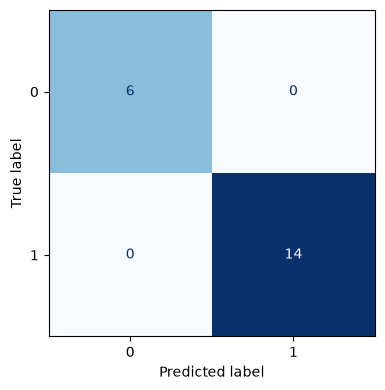

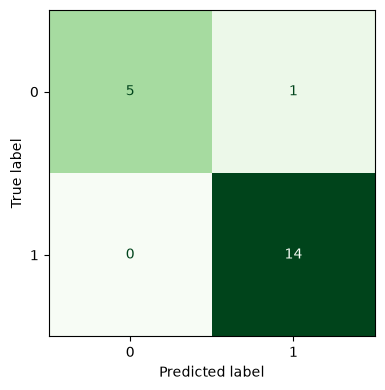

In [10]:
for name,pred,cmap in [
("logistic",log_pred,"Blues"),
("random_forest",rf_pred,"Greens")
]:
    fig,ax=plt.subplots(figsize=(5,4))
    ConfusionMatrixDisplay(
        confusion_matrix(y_test,pred)
    ).plot(ax=ax,cmap=cmap,colorbar=False)
    plt.tight_layout()
    plt.savefig(f"../images/confusion_matrix_{name}.png",dpi=300)
    plt.show()


## ROC Curve

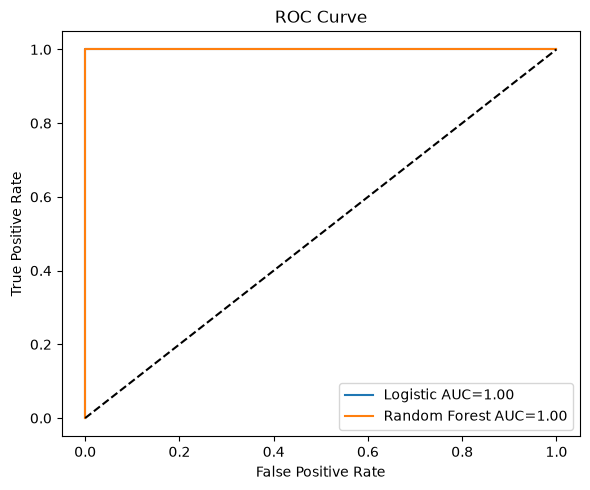

In [11]:
plt.figure(figsize=(6,5))
for name,model in [("Logistic",log_model),("Random Forest",rf_model)]:
    proba=model.predict_proba(X_test)[:,1]
    fpr,tpr,_=roc_curve(y_test,proba)
    auc=roc_auc_score(y_test,proba)
    plt.plot(fpr,tpr,label=f"{name} AUC={auc:.2f}")

plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.tight_layout()
plt.savefig("../images/roc_curve.png",dpi=300)
plt.show()


## Feature Importance

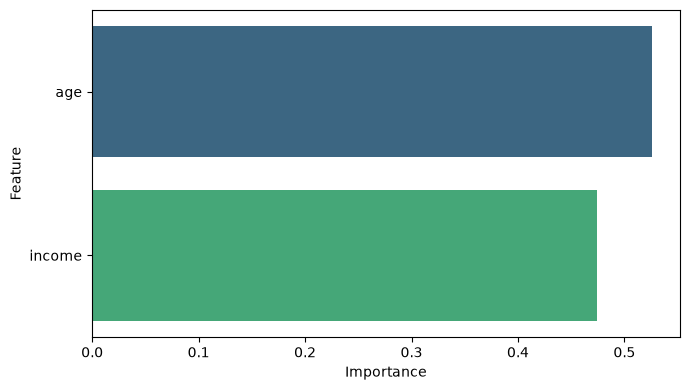

,Feature,Importance
0,age,0.525939
1,income,0.474061


In [12]:
importance=pd.DataFrame({
"Feature":X.columns,
"Importance":rf_model.feature_importances_
}).sort_values("Importance",ascending=False)

plt.figure(figsize=(7,4))
sns.barplot(data=importance,x="Importance",y="Feature",palette="viridis")
plt.tight_layout()
plt.savefig("../images/random_forest_feature_importance.png",dpi=300)
plt.show()

importance


## Model Comparison

In [13]:
results=pd.DataFrame({
"Model":["Logistic Regression","Random Forest"],
"Accuracy":[
accuracy_score(y_test,log_pred),
accuracy_score(y_test,rf_pred)
]
})

results.to_csv("../outputs/model_comparison.csv",index=False)
results


,Model,Accuracy
0,Logistic Regression,1.00
1,Random Forest,0.95


## Save Model

In [14]:
best_model=rf_model if results.iloc[1,1]>=results.iloc[0,1] else log_model

joblib.dump(best_model,"../models/model.pkl")
joblib.dump(scaler,"../models/scaler.pkl")

print("Saved model and scaler successfully.")


Saved model and scaler successfully.


# Conclusion

This notebook completed the Project 1 model training workflow.

Generated Files

## Models
- models/model.pkl
- models/scaler.pkl

## Images
- confusion_matrix_logistic.png
- confusion_matrix_random_forest.png
- roc_curve.png
- random_forest_feature_importance.png

## Outputs
- model_comparison.csv
